# Olay Atfetme Denemesi — üç negatif sonuç ve nedenleri

**Konum:** `experiments/notebooks/05_crisis_analysis/04_event_attribution_attempt.ipynb`
**Tarih:** 18 Ağustos 2026
**Önce oku:** `01_counterfactual_model.ipynb` · `03_gas_tariff_discovery.ipynb`

## Soru

Kontrafaktüel aleti hazır (`crisis_cf_v5`). Planın §8 adım 7'si şunu soruyordu:

> *"2021'den bu yana en anormal N günün kaçının tanımlı bir sebebi var, hangi kanaldan?"*

Bu notebook o soruyu üç farklı yoldan test eder. **Üçü de negatif sonuçlandı.**
Kayıt burada tutuluyor ki bir sonraki oturum aynı üç yolu tekrar denemesin.

## Özet

| # | Deneme | Sonuç |
|---|---|---|
| 1 | Kural filtresi: anormal günlerde daha çok aday haber var mı | **Hayır** (p = 0,95; kontrol günlerinde *daha fazla*) |
| 2 | Elle etiketleme (182 haber, kör): alaka skoru ayrışıyor mu | **Hayır** (p = 0,74) |
| 3 | Korpus teşhisi: bilinen krizlerde kanal yoğunluğu sıçrıyor mu | **5'te 2** |

## Neden negatif çıktığı — yapısal sebep

Model **bilinçli olarak** o saatin gerçekleşen arz kırılımını görüyor (`kgup_gas_lag0` vb.).
İran kesildiğinde gazdan üretim 11.837 → 8.453 MW düşüyor ve model bunu görüp yüksek
fiyat tahmin ediyor. **Yani olayın mekanik etkisi zaten kontrafaktüelin içinde.**

Kalıntı, olayın etkisi çıkarıldıktan *sonra* kalan şey. "Haberler kalıntıyı açıklıyor mu"
sorusu aslında şuydu: *"gaz kesintisi haberi, gaz kesintisinin fiyata yaptığı etkinin
ÖTESİNDE bir şey öngörüyor mu?"* Cevabın hayır çıkması tasarımın doğal sonucu.

Planın §3.3'ü bunu zaten söylüyordu: haberin veriye kattığı benzersiz şey sadece
**ileriye dönük duyuru**. Ve aşağıda göreceğiz: o çok seyrek.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().resolve().parents[2]
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import text
from db.connection import get_db_engine

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 4.5)
pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 40)

engine = get_db_engine()

# Analiz modelinin birincil sürümü. crisis_cf_v2/v3/v4 karşılaştırma içindir,
# analizde kullanma (gerekçe: 02_model_bias_investigation.ipynb §7).
VARIANT = 'fundamental'
MODEL   = 'crisis_cf_v1'

def cf(model=None, variant=None, where=''):
    """gold.crisis_counterfactual okuma yardımcısı — saat indeksli, tz-aware."""
    q = text(f"""
        SELECT ts, actual_usd, counterfactual_usd, residual_usd, at_cap, is_lower_bound, fold_id
        FROM gold.crisis_counterfactual
        WHERE variant = :v AND model_name = :m {where}
        ORDER BY ts
    """)
    d = pd.read_sql(q, engine, params={'v': variant or VARIANT, 'm': model or MODEL})
    d['ts'] = pd.to_datetime(d['ts'], utc=True).dt.tz_convert('Europe/Istanbul')
    for c in ['actual_usd', 'counterfactual_usd', 'residual_usd']:
        d[c] = d[c].astype(float)
    return d.set_index('ts')

print('bağlantı hazır')

bağlantı hazır


## 1. En anormal günler (v5 ile)

v1 ile üretilen liste Şubat 2023'e yığılıyordu — o bir model sapmasıydı, bkz. `02`.
v5 ile liste 2022'ye kayıyor, ki kriz yılı odur.

In [2]:
MODEL_V5 = 'crisis_cf_v5'
d = cf(model=MODEL_V5)
unc = d[~d.at_cap]
lo, hi = unc.residual_usd.quantile([.05, .95])
print(f'v5 boş band: p5={lo:+.1f}  p95={hi:+.1f}')

gb = d.groupby(d.index.date)
gun = gb.agg(gercek=('actual_usd', 'mean'), kontraf=('counterfactual_usd', 'mean'),
             kalinti=('residual_usd', 'mean'), tavan=('at_cap', 'sum'), n=('actual_usd', 'size'))
gun['band_ustu'] = gb.residual_usd.apply(lambda s: int((s > hi).sum()))
gun = gun[gun.n >= 20]
gun.index = pd.to_datetime(gun.index)

top = gun.reindex(gun.kalinti.abs().sort_values(ascending=False).index)
display(top.head(15).round(1))
print('\nen anormal 40 günün yıl dağılımı:')
print(top.head(40).groupby(top.head(40).index.year).size().to_string())

v5 boş band: p5=-19.9  p95=+23.3


,gercek,kontraf,kalinti,tavan,n,band_ustu
2022-04-10,10.6,47.3,-36.8,0,24,0
2022-10-23,167.0,131.7,35.3,3,24,17
2022-09-01,194.4,228.9,-34.5,0,24,0
2023-01-21,174.8,140.5,34.3,7,24,17
2022-10-22,195.7,161.4,34.3,4,24,14
2021-10-23,97.7,64.4,33.4,7,24,20
2022-08-31,198.3,165.4,32.9,13,24,17
2022-05-08,85.0,53.1,31.9,4,24,15
2022-07-11,134.4,102.5,31.9,3,24,16
2022-12-04,192.8,161.0,31.9,5,24,13



en anormal 40 günün yıl dağılımı:
2021     3
2022    28
2023     8
2024     1


## 2. Deneme 1 — kural filtresi, ve neden kontrol grubu şart

GÖP fiyatı D−1'de belirlenir; D−2 ve D−1'de yayımlanan haberler tahmin anında bilinebilir.
Her anormal gün için o penceredeki filtreyi geçen haberler sayılır.

**Kritik:** "38/40 günde aday var" tek başına anlamsızdır — filtre haberlerin %20'sini
geçiriyor, yani rastgele bir 2 günlük pencerede de aday çıkar. Kontrol grubu olmadan
bu sayı okunamaz.

In [3]:
from src.crisis.prefilter import decision_sql
from scipy import stats
rng = np.random.default_rng(42)

sayim_sql = text('WITH k AS (%s) SELECT count(*) n FROM k '
                 'WHERE gecti AND published_at >= :a AND published_at < :b' % decision_sql())

def aday_say(gunler, conn):
    return np.array([conn.execute(sayim_sql, {
        'a': (g - pd.Timedelta(days=2)).strftime('%Y-%m-%d'),
        'b': g.strftime('%Y-%m-%d')}).scalar() for g in gunler])

anom = top.head(40).index
with engine.connect() as conn:
    a_say = aday_say(anom, conn)
    tum = pd.to_datetime(pd.read_sql(text("""
        SELECT DISTINCT (ts AT TIME ZONE 'Europe/Istanbul')::date d
        FROM gold.crisis_counterfactual WHERE model_name = 'crisis_cf_v5'"""), conn).d)
    ktrl = []
    for yil, k in pd.Series(anom.year).value_counts().items():
        havuz = tum[(tum.dt.year == yil) & (~tum.isin(anom))]
        ktrl.extend(rng.choice(havuz.values, size=min(k * 10, len(havuz)), replace=False))
    k_say = aday_say(pd.DatetimeIndex(ktrl), conn)

u, p = stats.mannwhitneyu(a_say, k_say, alternative='greater')
print('anormal günler   n=%3d  ort %.2f  medyan %.0f' % (len(a_say), a_say.mean(), np.median(a_say)))
print('kontrol günleri  n=%3d  ort %.2f  medyan %.0f' % (len(k_say), k_say.mean(), np.median(k_say)))
print('\nMann-Whitney tek yönlü p = %.3f' % p)

anormal günler   n= 40  ort 5.15  medyan 4
kontrol günleri  n=400  ort 6.11  medyan 5

Mann-Whitney tek yönlü p = 0.947


### 📌 Deneme 1 Analiz Notları

- Anormal günlerde **5,15**, kontrol günlerinde **6,11** aday. p = 0,95.
- Anormal günlerde aday sayısı fazla değil, **hatta az**.
- "38/40 günün adayı var" cümlesi anlamsız: kontrol günlerinin de %97'sinin var.
- Filtre hacmi 5 kat azaltıyor ama **olay tanımlamıyor.**

## 3. Deneme 2 — elle etiketlenmiş altın küme (182 haber)

"Filtre kaba olduğu için olmadı" hipotezini test etmek için 182 haber şemaya göre
elle etiketlendi: `src/crisis/gold/gold_labels_182.json`.

**Küme tasarımı:** rastgele değil — v5'in en anormal **20 günü** + aynı yıl dağılımından
**20 kontrol günü**, her günün D−2/D−1 penceresindeki filtreyi geçen haberler.
Etiketleme sırasında haberin hangi gruba ait olduğu **görülmedi**.

**Uyarı:** bu küme kappa'nın *insan* tarafı değildir. Bir LLM tarafından üretildi;
LLM'i buna karşı ölçmek LLM-vs-LLM olur. Few-shot örneği, şema doğrulaması ve
dışsal geçerlilik testi için kullanılabilir.

In [4]:
import json as _json
from src.crisis.labeling_schema import validate

gold = _json.loads((project_root / 'src/crisis/gold/gold_labels_182.json').read_text(encoding='utf-8'))
lab = pd.DataFrame(gold['etiketler'])
print('etiket:', gold['n'])

# ŞEMA DOĞRULAMASI — bu testin kendisi planın §8 adım 1'idir
hata = []
for r in gold['etiketler']:
    o = {'alaka_skoru': r['alaka_skoru'], 'kanal': r['kanal'], 'yon': r['yon'],
         'ileriye_donuk': bool(r['ileriye_donuk']), 'etki_baslangici': r['etki_baslangici'],
         'sure_gun': r['sure_gun'],
         'miktar': ({'deger': r['miktar_deger'], 'birim': r['miktar_birim']}
                    if r['miktar_deger'] is not None else None),
         'ozet': r['ozet']}
    try:
        validate(o)
    except Exception as ex:
        hata.append((r['article_id'], str(ex)))
print('şema doğrulaması: %d/%d geçti' % (len(lab) - len(hata), len(lab)))

print()
print('alaka skoru dağılımı:')
print(lab.alaka_skoru.describe()[['mean', '50%', 'max']].round(2).to_string())
print('alaka >= 0.4 olan: %d (%%%.0f)' % ((lab.alaka_skoru >= .4).sum(),
                                          100 * (lab.alaka_skoru >= .4).mean()))
print()
print('en yüksek alakalı 8 haber:')
display(lab.nlargest(8, 'alaka_skoru')[['article_id', 'published_at', 'alaka_skoru', 'kanal', 'yon', 'title']])

etiket: 182
şema doğrulaması: 182/182 geçti

alaka skoru dağılımı:
mean    0.13
50%     0.05
max     0.95
alaka >= 0.4 olan: 17 (%9)

en yüksek alakalı 8 haber:


,article_id,published_at,alaka_skoru,kanal,yon,title
21,52175,2022-12-30,0.95,regulation,asagi,Elektrik tavan fiyatı düştü: 4.200 TL
29,46182,2021-12-31,0.90,fuel_cost,yukari,İşte yeni yılda zamlı doğalgaz fiyatları!
24,47495,2022-03-17,0.80,regulation,asagi,EPDK elektrik fiyatlarına müdahale edebilecek
143,44992,2021-10-19,0.75,regulation,yukari,EMO: Spot elektrik tavan fiyatı otomatik artacak
167,43475,2021-06-30,0.70,supply_capacity,yukari,Elektrik fiyatları tavan yaptı!
180,54629,2023-06-24,0.60,regulation,yukari,EÜAŞ aktif toptan satış tarifesine zam
81,49838,2022-08-22,0.55,supply_capacity,yukari,Kuzey Akım’dan gaz akışı 3 gün duracak
22,43451,2021-06-29,0.50,supply_capacity,asagi,TürkAkım’da bakım ve onarım çalışmaları erken ...


### 📌 Şema testi (plan §8 adım 1) kendiliğinden koştu — ve şema kazandı

İlk etiketlemede doğrulayıcı **182'nin 19'unu reddetti**, hepsi aynı kuraldan:
`ileriye_donuk=false` iken `miktar`/`sure_gun` dolu olamaz. Geçmişi anlatan sayıları
("%106 arttı", "445 MW kaldı") doz alanına yazmıştım; şema bunu yasaklıyor çünkü o alan
**ileriye dönük** duyurular için.

Yani çapraz alan kısıtı, yetkin bir etiketleyicinin **%10 hatasını** yakaladı. LLM'in
aynı hatayı daha sık yapması beklenir; GBNF grameri bunu üretim anında engelleyecek.
Bu, şemanın gerçek veriyle ilk teması ve ayakta kaldı.

In [5]:
# Anormal gün vs kontrol günü — gün bazında alaka istatistikleri
from src.crisis.prefilter import decision_sql as _ds

esles_sql = text('WITH k AS (%s) SELECT k.article_id, k.published_at::date d FROM k '
                 'WHERE k.gecti AND k.published_at >= :a AND k.published_at < :b' % _ds())

anom20 = top.head(20).index
rng2 = np.random.default_rng(7)
with engine.connect() as conn:
    tum2 = pd.to_datetime(pd.read_sql(text(
        "SELECT DISTINCT (ts AT TIME ZONE 'Europe/Istanbul')::date d "
        "FROM gold.crisis_counterfactual WHERE model_name='crisis_cf_v5'"), conn).d)
    ktrl20 = []
    for yil, k in pd.Series(anom20.year).value_counts().items():
        havuz = tum2[(tum2.dt.year == yil) & (~tum2.isin(anom20))]
        ktrl20.extend(rng2.choice(havuz.values, size=k, replace=False))
    ktrl20 = pd.DatetimeIndex(ktrl20)

    satir = []
    for grup, gunler in [('A', anom20), ('K', ktrl20)]:
        for g in gunler:
            h = pd.read_sql(esles_sql, conn, params={
                'a': (g - pd.Timedelta(days=2)).strftime('%Y-%m-%d'),
                'b': g.strftime('%Y-%m-%d')})
            h['grup'] = grup
            h['hedef_gun'] = g.date()
            satir.append(h)

esl = pd.concat(satir).drop_duplicates(subset=['article_id', 'hedef_gun'])
m = esl.merge(lab[['article_id', 'alaka_skoru']], on='article_id')

gun_ist = m.groupby(['grup', 'hedef_gun']).agg(
    n=('alaka_skoru', 'size'), maks=('alaka_skoru', 'max'),
    toplam=('alaka_skoru', 'sum'), guclu=('alaka_skoru', lambda s: (s >= .4).sum()))
display(gun_ist.groupby('grup').mean().round(2))

A, K = gun_ist.loc['A'], gun_ist.loc['K']
for kol in ['maks', 'toplam', 'guclu']:
    _, p = stats.mannwhitneyu(A[kol], K[kol], alternative='greater')
    print('%-8s A=%.2f  K=%.2f   p=%.3f  %s' % (kol, A[kol].mean(), K[kol].mean(), p,
                                                'ANLAMLI' if p < .05 else 'fark yok'))

,n,maks,toplam,guclu
grup,,,,
A,4.75,0.30,0.60,0.35
K,5.50,0.36,0.76,0.61


maks     A=0.30  K=0.36   p=0.741  fark yok
toplam   A=0.60  K=0.76   p=0.772  fark yok
guclu    A=0.35  K=0.61   p=0.861  fark yok


### 📌 Deneme 2 Analiz Notları — darboğaz etiketleme kalitesi DEĞİL

| | anormal gün | kontrol günü | p |
|---|---|---|---|
| En yüksek alaka | 0,30 | **0,36** | 0,741 |
| Toplam alaka | 0,60 | **0,76** | 0,772 |
| Güçlü olay (≥0,4) | 0,35 | **0,61** | 0,861 |

- Hiçbir ölçüde fark yok; kontrol günleri üçünde de hafifçe önde.
- Deneme 1 başarısız olunca "araç kaba" diyebiliyorduk. Burada araç nitelikli — şemaya
  uygun, kör, insan okumasıyla — **ve sonuç değişmedi.**
- 182 haberin sadece **%9'u** alaka ≥ 0,4 aldı. Gerçek piyasa olayları tanımlanabiliyor
  (tavan değişikliği 0,95 · elektrik üretim gazına %15 zam 0,90 · tavan %48 arttı 0,75)
  ama anormal günlerde yoğunlaşmıyorlar.
- **Sonuç: sorun etiketleme kalitesinde değil, bu korpusun anormal günlerle
  ilişkisinde.**

## 4. Deneme 3 — korpus teşhisi: yoğunluk endeksi kurulabilir mi

Denemeler 1 ve 2 **günlük** frekansta ve **tekil olay** çerçevesindeydi. Ama büyük
olayların tarihi yoktur, yörüngesi vardır: Rusya-Ukrayna savaşı 24 Şubat 2022'de fiyatı
sıçratmadı; TTF aylar içinde tırmandı, BOTAŞ tarifesi 12 ayda 2.060 → 20.625 TL'ye çıktı.

Literatürdeki karşılığı **sürekli yoğunluk endeksi** (Baker-Bloom-Davis EPU,
Caldara-Iacoviello GPR): olay saymak yerine haber akışındaki yoğunluğu ölçmek, ve
haftalık/aylık frekansta çalışmak.

Endeksi kurmadan önce dört teşhis — hepsi endeksin yaşayıp yaşamayacağını baştan söyler.

In [6]:
from src.crisis.prefilter import decision_sql as _ds2

q_all = text('WITH k AS (%s) SELECT published_at, section, gecti, kanallar FROM k '
             'WHERE published_at >= :a AND published_at < :b' % _ds2())
korpus = pd.read_sql(q_all, engine, params={'a': '2021-01-01', 'b': '2026-08-19'})
korpus['published_at'] = pd.to_datetime(korpus.published_at, utc=True).dt.tz_convert('Europe/Istanbul')
korpus['hafta'] = korpus.published_at.dt.tz_localize(None).dt.to_period('W').dt.start_time

# 1) hacim stabil mi
hafta_n = korpus.groupby('hafta').size()
yil = korpus.groupby(korpus.published_at.dt.year).size()
gun_say = korpus.groupby(korpus.published_at.dt.year).published_at.apply(lambda s: (s.max() - s.min()).days + 1)
print('haftalık hacim: ort %.1f  medyan %.0f  std %.1f  (n=%d hafta)'
      % (hafta_n.mean(), hafta_n.median(), hafta_n.std(), len(hafta_n)))
display(pd.DataFrame({'haber': yil, 'gun': gun_say, 'haber_gun': (yil / gun_say).round(1)}))

# 4) editoryal kayma
pay = pd.crosstab(korpus.published_at.dt.year, korpus.section, normalize='index').mul(100).round(1)
kolon = [c for c in ['Elektrik', 'Doğalgaz', 'Petrol', 'Güneş', 'Rüzgar', 'Kömür'] if c in pay.columns]
print()
print('bölüm paylarının yıllara göre değişimi (%) — editoryal kayma ölçüsü:')
display(pay[kolon])

haftalık hacim: ort 95.6  medyan 96  std 17.9  (n=294 hafta)


,haber,gun,haber_gun
published_at,,,
2021,5392,365,14.8
2022,5862,365,16.1
2023,4846,365,13.3
2024,4466,366,12.2
2025,4575,365,12.5
2026,2961,228,13.0



bölüm paylarının yıllara göre değişimi (%) — editoryal kayma ölçüsü:


section,Elektrik,Doğalgaz,Petrol,Güneş,Rüzgar,Kömür
published_at,,,,,,
2021,31.4,11.9,19.3,6.6,4.3,4.9
2022,26.2,13.4,19.5,9.3,4.8,4.4
2023,27.4,9.1,20.3,9.7,6.6,3.3
2024,29.0,8.7,17.5,11.3,7.1,4.0
2025,32.2,7.8,16.4,11.5,6.6,3.0
2026,32.3,9.7,19.8,8.6,6.2,3.0


,ort_pay%,std%,degiskenlik,maks_z
fuel_cost,3.1,2.2,0.70,3.6
supply_capacity,7.7,4.1,0.53,2.7
demand,0.9,1.2,1.34,5.4
regulation,21.1,6.7,0.32,5.7
fx_macro,0.4,0.8,1.76,7.5
renewable,2.2,1.7,0.78,4.0



bilinen kriz pencerelerinde kanal z-skorları:


,fuel_cost,supply_capacity,demand,regulation,fx_macro,renewable
İran gaz kesintisi (Oca 22),1.4,0.5,2.6,-0.1,0.1,-0.9
Rusya-Ukrayna (Şub 22),1.5,-0.5,-0.1,0.1,0.2,-0.2
Eylül 2022 gaz zirvesi,0.1,-0.4,1.1,1.4,0.3,-0.3
İran-İsrail (Haz 25),0.0,-0.2,-0.7,-0.5,-0.6,0.6
Şubat 2023 deprem,0.9,-0.2,0.1,-0.7,-0.1,-0.4


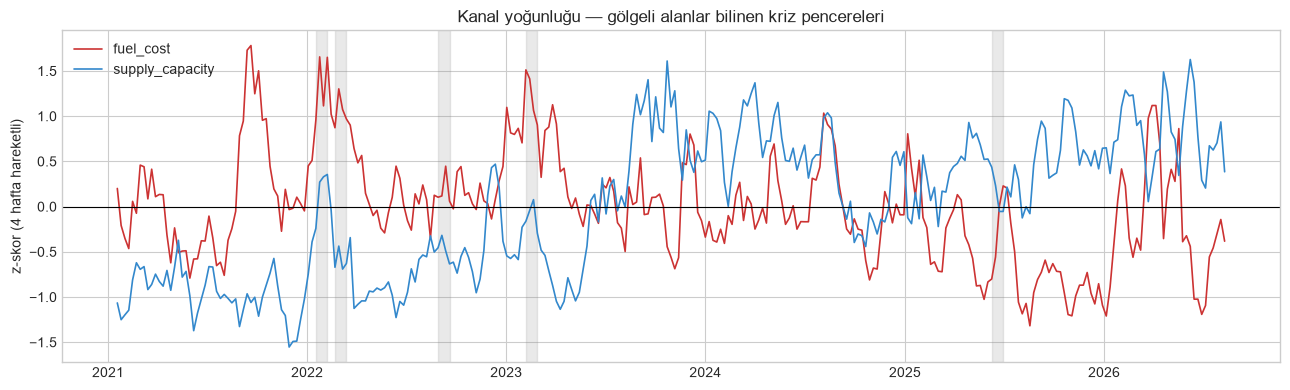

In [7]:
# 2) kanal payları gerçekten değişiyor mu, 3) bilinen krizlerde sıçrıyor mu
KANALLAR = ['fuel_cost', 'supply_capacity', 'demand', 'regulation', 'fx_macro', 'renewable']
toplam = korpus.groupby('hafta').size()
paylar = {}
for k in KANALLAR:
    c = korpus[korpus.kanallar.apply(lambda x: k in x)].groupby('hafta').size()
    paylar[k] = c.reindex(toplam.index, fill_value=0) / toplam
P_ = pd.DataFrame(paylar)
Z = (P_ - P_.mean()) / P_.std()

display(pd.DataFrame({'ort_pay%': (100 * P_.mean()).round(1),
                      'std%': (100 * P_.std()).round(1),
                      'degiskenlik': (P_.std() / P_.mean()).round(2),
                      'maks_z': Z.max().round(1)}))

KRIZ = {'İran gaz kesintisi (Oca 22)': ('2022-01-17', '2022-02-07'),
        'Rusya-Ukrayna (Şub 22)':      ('2022-02-21', '2022-03-14'),
        'Eylül 2022 gaz zirvesi':      ('2022-08-29', '2022-09-19'),
        'İran-İsrail (Haz 25)':        ('2025-06-09', '2025-06-30'),
        'Şubat 2023 deprem':           ('2023-02-06', '2023-02-27')}
print()
print('bilinen kriz pencerelerinde kanal z-skorları:')
sat = {}
for ad, (a, b) in KRIZ.items():
    msk = (Z.index >= a) & (Z.index < b)
    sat[ad] = Z[msk].mean()
display(pd.DataFrame(sat).T.round(1))

fig, ax = plt.subplots(figsize=(13, 4))
for k, c in [('fuel_cost', '#c33'), ('supply_capacity', '#38c')]:
    ax.plot(Z.index, Z[k].rolling(4).mean(), label=k, color=c, lw=1.2)
for a, b in KRIZ.values():
    ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='#888', alpha=.18)
ax.axhline(0, color='k', lw=.8)
ax.set_ylabel('z-skor (4 hafta hareketli)'); ax.legend()
ax.set_title('Kanal yoğunluğu — gölgeli alanlar bilinen kriz pencereleri')
plt.tight_layout(); plt.show()

### 📌 Deneme 3 Analiz Notları — altyapı sağlam, kanal tanımı değil

**Yaşayan kısım:**
- Haftalık hacim **stabil**: ort 95,6, std 17,9; günlük 12,2–16,1 arası, trend yok
- Kanal payları **düz gürültü değil**: değişkenlik 0,32–1,76, maks z 2,7–7,5

**Sorunlu kısım — editoryal kayma:** Doğalgaz payı %11,9 → %7,8 (−%35),
Güneş %6,6 → %11,5 (+%74). `fuel_cost` endeksine sistematik aşağı eğim bindirir.
Somut kanıtı zaten var: site 2025 Mart'tan sonra aylık BOTAŞ tarife haberlerini
yazmayı bıraktı (bkz. `03` §5, Nisan 2025 boşluğu).

**Belirleyici test — 5'te 2:**

| Pencere | Beklenen | Gerçekleşen |
|---|---|---|
| İran gaz kesintisi | fuel_cost / supply | fuel_cost **+1,4**, demand **+2,6** ✓ |
| Rusya-Ukrayna | fuel_cost | fuel_cost **+1,5** ✓ |
| Eylül 2022 gaz zirvesi | fuel_cost | +0,1 ✗ |
| **İran-İsrail (Haz 25)** | fuel_cost | **+0,0** ✗ |
| Şubat 2023 deprem | demand | +0,1 ✗ |

**Başarısızlıkların sebebi aynı değil.** Deprem için `demand` kanalının terimleri
"tüketim rekor / puant / tasarruf / soğuk hava" — depremi yakalayacak hiçbir terim yok.
Bu **filtre tasarım hatası**, korpus eksikliği değil.

Ama İran-İsrail'de sıfır çıkması filtreyle açıklanamaz: `fuel_cost` listesinde
"gaz fiyat", "ttf", "fiyat artır" var.

**Teşhis: filtre tek bir vakaya kalibre edilmiş** (İran 2022; recall çıpası oydu) ve
genelleşmiyor. Endeks fikri ölmüyor ama önkoşul koyuyor: **kanalları elle tanımlamayı
bırakmak.** Konu modelleme (BERTopic/LDA) burada süs değil gerekli adım — korpus kendi
konularını çıkarsın, biz İran vakasından türettiğimiz altı kanalı dayatmayalım.

## 5. Nerede duruyoruz

**Çalışan ve duran şeyler:**
- Kontrafaktüel aleti (`crisis_cf_v5`) — sağlam, doğrulanmış, İran vakasını ölçüyor
- İki yapılandırılmış seri (`price_cap_official`, `gas_tariff_electricity`) — haber
  arşivinden *madencilikle* çıkarıldı, etiketleme hattıyla değil
- Haber arşivi + tam metin araması — insan analist için gerçek bir araç

**Çalışmayan:** haberden günlük olay atfetme. Üç bağımsız test, üçü de negatif.

**Yapısal sebep:** model olayın dozunu zaten görüyor (`kgup_gas_lag0`), dolayısıyla
kalıntı olayın etkisi *çıkarıldıktan sonra* kalan şey. Haberin katabileceği tek benzersiz
bilgi **ileriye dönük duyuru** ve o çok seyrek — 182 haberde bir avuç.

**Senin sorunun cevabı ikiye ayrılıyor:**

| Soru | n | Cevaplanabilir mi |
|---|---|---|
| "Tavan değişirse fiyat ne olur" | ~30 | **Evet** — seri hazır, olay çalışması yapılabilir |
| "Gaz tarifesi değişirse" | ~30 | **Evet** — aynı |
| "Savaş çıkarsa" | 2 | Hayır — ama *"savaş yakıt maliyetini şu kadar itti, o da fiyata şu kadar geçti"* ölçülebilir |
| "Gaz kesintisi olursa" | 3-5 | Hayır — vaka çalışması evet, genelleme hayır |

**Açık kalan yollar (öncelik sırasıyla):**
1. Tavan + tarife değişiklikleri için olay çalışması — n yeterli, veri hazır, yarım gün
2. `raw_bids_offers_hourly` — kalıntı muhtemelen olay değil **teklif davranışı**; hiç dokunulmadı
3. EPİAŞ santral bazlı arıza/bakım bildirimleri — yapılandırılmış olay verisi, haberden üstün
4. Konu modelleme → yoğunluk endeksi (kanal tanımını korpusa bıraktıktan sonra)
5. İkinci haber kaynağı (`enerjiportali.com` fizibilitede HTTP 523 veriyordu)